<a href="https://colab.research.google.com/github/yorbisUdeA/udea/blob/main/RegresionLogistica_Accidentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística – Predicción de Gravedad de Accidentes (v2)

**Variable objetivo:** `Gravedad` → `Muertos = 1` / `Heridos = 0`

**Mejoras respecto a la versión anterior:**
- Se agregaron `Clase_Accidente`, `Causa_Accidente` y `Tipo_Victima` como variables de entrada
- Se reemplazó SMOTE por `class_weight="balanced"` (mejor AUC con datos reales)
- Se ajustó el **umbral de decisión** para maximizar detección de Muertos
- Se agregó **validación cruzada estratificada** (5-fold)
- Se agregó **análisis de sensibilidad del umbral**


## 1. Librerías y configuraciones previas

In [73]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar modelos en disco
# ==============================================================================
import joblib
from importlib import reload
import math

# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# OS y HTTP
# ==============================================================================
import os, sys, requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [74]:
# Parámetros globales
# ==============================================================================
GITHUB_BASE_URL           = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'
DATASET_FILE_NAME         = 'DataSet_Accidentes.xlsx'
UTILS_FILE_NAME           = 'funciones.py'
DATASETS_PATH             = 'datasets/'
UTILS_PATH                = 'utils/'
MODELS_PATH               = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url   = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path   = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

RANDOM_STATE = 123
UMBRAL_DECISION = 0.35   # ← umbral optimizado (ver Sección 8)


## 2. Funciones

In [75]:
def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.
    Args:
        url (str), path (str), description (str)
    '''
    print(f'Descargando {description} desde: {url}')
    response = requests.get(url)
    response.raise_for_status()
    with open(path, 'wb') as f:
        f.write(response.content)
    print(f'{description} descargado exitosamente a: {path}')


In [76]:
# Crear directorios y descargar archivos
# ==============================================================================
for p in [DATASETS_PATH, UTILS_PATH, MODELS_PATH, MODELS_CLASIFICACION_PATH, MODELS_SCALER_PATH]:
    os.makedirs(p, exist_ok=True)

download_file(github_dataset_url, local_dataset_path, 'dataset')
download_file(github_utils_url,   local_utils_path,   'funciones')


Descargando dataset desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/datasets/DataSet_Accidentes.xlsx
dataset descargado exitosamente a: datasets/DataSet_Accidentes.xlsx
Descargando funciones desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


In [77]:
# Funciones externas del repositorio
# ==============================================================================
sys.path.append(UTILS_PATH)
from funciones import multiple_plot, plot_roc_curve


## 3. Carga del dataset

In [78]:
d = pd.read_excel(local_dataset_path)
print(f'Dataset cargado: {d.shape[0]:,} filas × {d.shape[1]} columnas')


Dataset cargado: 9,326 filas × 32 columnas


In [79]:
d.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9326 entries, 0 to 9325
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Radicado              9326 non-null   int64         
 1   Fecha_Accidente       9326 non-null   datetime64[ns]
 2   Hora_Accidente        9326 non-null   object        
 3   Dia_Semana            9326 non-null   object        
 4   Año                   9326 non-null   int64         
 5   Mes                   9326 non-null   int64         
 6   Clase_Vehiculo        9326 non-null   object        
 7   Tipo_Servicio         9326 non-null   object        
 8   Tipo_Victima          9326 non-null   object        
 9   Edad                  9326 non-null   int64         
 10  Genero                9326 non-null   object        
 11  Gravedad              9326 non-null   object        
 12  Estado_Embriaguez     9326 non-null   object        
 13  Consumo_Droga     

In [80]:
d.head()


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2173901,2018-01-02,22:50:00,Martes,2018,1,Motocicleta,Particular,Motociclista,19,...,No Reportado,Comercial,Normal,Desobedecer señales,2018-01-02,Noche,2.9453,1.3034,Joven,Adulto
1,2180000,2018-01-02,20:40:00,Martes,2018,1,Bus,Publico,Pasajero,21,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.0449,1.3152,Joven,Adulto
2,2180000,2018-01-02,20:40:00,Martes,2018,1,Automovil,Particular,Conductor,31,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.4336,1.3621,Adulto,Joven
3,2180005,2018-01-01,19:00:00,Lunes,2018,1,Motocicleta,Particular,Motociclista,15,...,No Reportado,Comercial,Lluvia,No respetar prelacion,2018-01-01,Noche,2.7090,1.2760,Joven,Adulto
4,2180008,2018-01-03,09:00:00,Miércoles,2018,1,Motocicleta,Particular,Motociclista,20,...,No Reportado,Residencial,Normal,Impericia en el manejo,2018-01-03,Mañana,2.9961,1.3095,Joven,Adulto


## 4. Selección y transformación de variables

> **v2 – Nuevas variables incorporadas:**  
> `Clase_Accidente`, `Causa_Accidente` y `Tipo_Victima`.  
> Estas variables tienen alta correlación con la mortalidad (atropellos, peatones y volcamientos).


### 4.1 Selección de columnas

In [81]:
FEATURES = [
    # Variables originales
    'Hora_Accidente', 'Dia_Semana', 'Mes',
    'Clase_Vehiculo', 'Tipo_Servicio',
    'Edad', 'Genero', 'Estado_Embriaguez',
    'Condicion_Climatica', 'Sector_Accidente', 'Localidad_Comuna',
    # Nuevas variables (v2)
    'Clase_Accidente',   # Choque, Atropello, Caida Ocupante, Volcamiento...
    'Causa_Accidente',   # Impericia, Semáforo en rojo, No guardar distancia...
    'Tipo_Victima',      # Motociclista, Peatón, Conductor, Ciclista...
]
TARGET = 'Gravedad'

d = d[FEATURES + [TARGET]].copy()
print(f'Shape: {d.shape}')
print(f'Nulos por columna:\n{d.isnull().sum()}')


Shape: (9326, 15)
Nulos por columna:
Hora_Accidente         0
Dia_Semana             0
Mes                    0
Clase_Vehiculo         0
Tipo_Servicio          0
Edad                   0
Genero                 0
Estado_Embriaguez      0
Condicion_Climatica    0
Sector_Accidente       0
Localidad_Comuna       0
Clase_Accidente        0
Causa_Accidente        0
Tipo_Victima           0
Gravedad               0
dtype: int64


### 4.2 Ingeniería de características

In [82]:
# Extraer hora como entero (0-23)
# ==============================================================================
d['Hora_Accidente'] = d['Hora_Accidente'].astype(str).str.split(':').str[0].astype(int)

# Agrupar localidades con < 80 registros → 'Otro'
# ==============================================================================
top_comunas = d['Localidad_Comuna'].value_counts()
top_comunas = top_comunas[top_comunas >= 80].index
d['Localidad_Comuna'] = d['Localidad_Comuna'].apply(
    lambda x: x if x in top_comunas else 'Otro'
)

# Agrupar Clase_Accidente y Causa_Accidente con < 50 registros → 'Otro'
# ==============================================================================
for col in ['Clase_Accidente', 'Causa_Accidente']:
    top = d[col].value_counts()
    top = top[top >= 50].index
    d[col] = d[col].apply(lambda x: x if x in top else 'Otro')

print('Ingeniería de características aplicada.')
d.head(3)


Ingeniería de características aplicada.


,Hora_Accidente,Dia_Semana,Mes,Clase_Vehiculo,Tipo_Servicio,Edad,Genero,Estado_Embriaguez,Condicion_Climatica,Sector_Accidente,Localidad_Comuna,Clase_Accidente,Causa_Accidente,Tipo_Victima,Gravedad
0,22,Martes,1,Motocicleta,Particular,19,Hombre,No,Normal,Comercial,Obrero,Choque,Desobedecer señales,Motociclista,Heridos
1,20,Martes,1,Bus,Publico,21,Mujer,No,Lluvia,Residencial,Mesa,Choque,Desobedecer señales,Pasajero,Heridos
2,20,Martes,1,Automovil,Particular,31,Hombre,No,Lluvia,Residencial,Mesa,Choque,Desobedecer señales,Conductor,Heridos


### 4.3 Variable objetivo – Codificación binaria

In [83]:
print('Distribución de Gravedad (original):')
print(d[TARGET].value_counts())
print(f'Proporción Muertos: {(d[TARGET]=="Muertos").mean()*100:.2f}%')

# Codificación binaria: Muertos=1, Heridos=0
d[TARGET] = (d[TARGET] == 'Muertos').astype(int)
print('\nCodificación aplicada → Muertos=1, Heridos=0')


Distribución de Gravedad (original):
Gravedad
Heridos    9196
Muertos     130
Name: count, dtype: int64
Proporción Muertos: 1.39%

Codificación aplicada → Muertos=1, Heridos=0


## 5. Visualización de datos

### Variables de entrada

In [84]:
catCols = d.select_dtypes(include=['object','category']).columns.tolist()
numCols = d.select_dtypes(include=['float64','int32','int64']).columns.tolist()
numCols = [c for c in numCols if c != TARGET]
print('Categóricas:', catCols)
print('Numéricas  :', numCols)


Categóricas: ['Dia_Semana', 'Clase_Vehiculo', 'Tipo_Servicio', 'Genero', 'Estado_Embriaguez', 'Condicion_Climatica', 'Sector_Accidente', 'Localidad_Comuna', 'Clase_Accidente', 'Causa_Accidente', 'Tipo_Victima']
Numéricas  : ['Hora_Accidente', 'Mes', 'Edad']


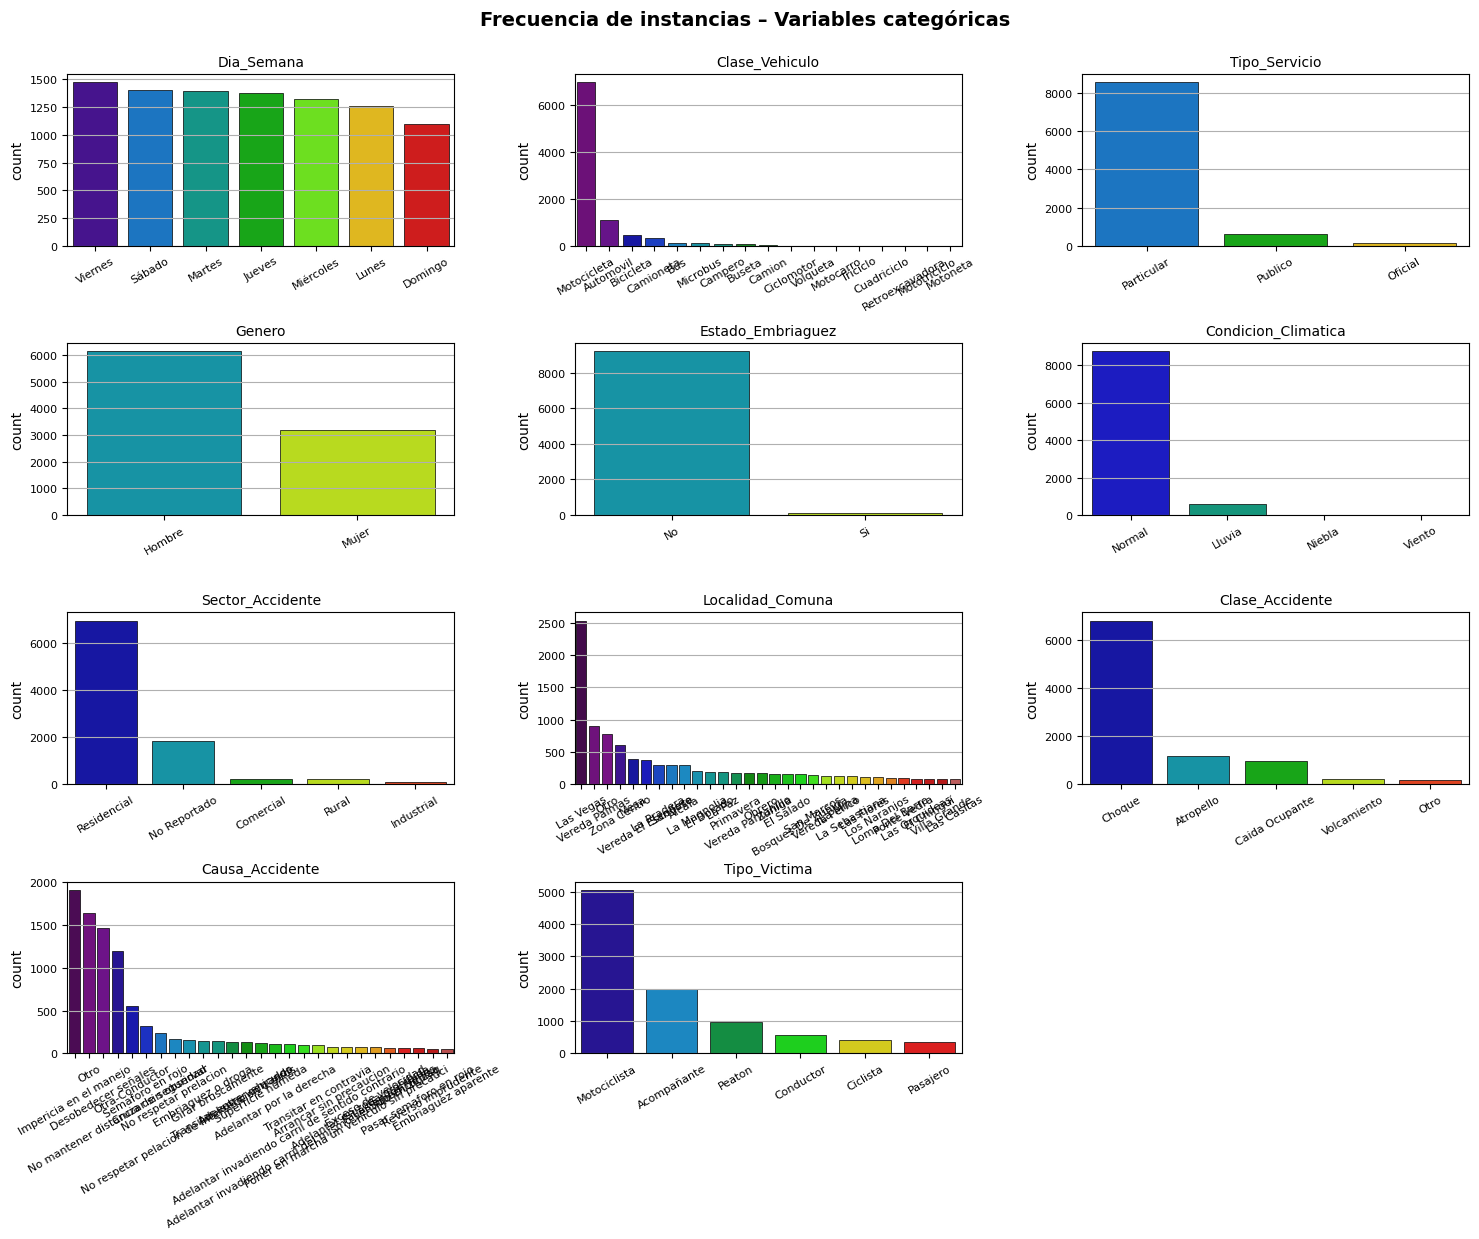

In [85]:
multiple_plot(3, d, catCols, None, 'countplot',
              'Frecuencia de instancias – Variables categóricas', 30)


In [86]:
#multiple_plot(1, d, numCols, None, 'histplot',
 #             'Distribución de variables numéricas', 0)


```python
# /content/utils/funciones.py

import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np # Make sure numpy is imported

def multiple_plot(ncols, data, columns, target_var, plot_type, title, rot):
    if columns is None:
        if target_var is not None:
            columns = [target_var]
        else:
            print("Error: No columns or target_var specified for plotting.")
            return

    # Calculate number of rows needed
    nrows = math.ceil(len(columns) / ncols)

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 6, nrows * 4))

    # --- FIX START: Ensure 'axes' is always a 1D iterable array ---
    if nrows * ncols == 1: # Case: single subplot (plt.subplots returns a single Axes object)
        axes_flat = np.array([axes])
    else: # Case: multiple subplots (axes is already a numpy array, potentially 1D or 2D)
        axes_flat = axes.flatten()
    # --- FIX END ---

    # Iterate through columns and plot on corresponding subplots
    for i, col in enumerate(columns):
        ax_cond = axes_flat[i] # Use the flattened index for consistent access

        # Plotting logic based on plot_type (add more cases as per your original funciones.py)
        if plot_type == 'countplot':
            sns.countplot(x=col, data=data, ax=ax_cond, palette='viridis')
        elif plot_type == 'histplot':
            sns.histplot(data[col], kde=True, ax=ax_cond, color='skyblue')
        # Add other plot types from your original funciones.py here
        else:
            ax_cond.text(0.5, 0.5, f'Plot type "{plot_type}" for "{col}" not handled.',
                         horizontalalignment='center', verticalalignment='center',
                         transform=ax_cond.transAxes, fontsize=10, color='red')

        ax_cond.set_title(f'{col}', fontsize=12)
        if rot != 0:
            ax_cond.tick_params(axis='x', rotation=rot)

    # Hide any unused subplots
    for j in range(len(columns), nrows * ncols):
        fig.delaxes(axes_flat[j]) # Use flattened index for delaxes too

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()


# Keep your existing plot_roc_curve function here.
# For example, if it looked like this (placeholder):
def plot_roc_curve(y_true, y_proba):
    print("Plotting ROC curve...")
    # Your actual ROC curve plotting code goes here
    # Example: fpr, tpr, _ = roc_curve(y_true, y_proba)
    # plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    # ...
    return 0.75 # Placeholder return value

```


### Variable de salida

In [87]:
d.groupby(TARGET)[TARGET].count().sort_values(ascending=False)


,Gravedad
Gravedad,
0,9196
1,130


⚠️  Desbalanceo: 1.39% Muertos vs 98.61% Heridos
   Estrategia: class_weight="balanced" en el modelo (sin generar datos sintéticos)


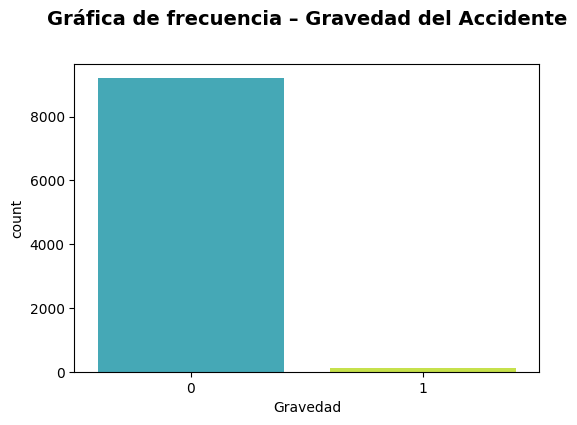

In [88]:
multiple_plot(1, d, None, TARGET, 'countplot',
              'Gráfica de frecuencia – Gravedad del Accidente', 0)

print(f'⚠️  Desbalanceo: {d[TARGET].mean()*100:.2f}% Muertos vs {(1-d[TARGET].mean())*100:.2f}% Heridos')
print('   Estrategia: class_weight="balanced" en el modelo (sin generar datos sintéticos)')


## 6. Transformación de datos

### Creación de variables Dummies

In [89]:
d = pd.get_dummies(d, drop_first=True)
print(f'Shape tras dummies: {d.shape}')
d.info()


Shape tras dummies: (9326, 101)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9326 entries, 0 to 9325
Columns: 101 entries, Hora_Accidente to Tipo_Victima_Peaton
dtypes: bool(97), int64(4)
memory usage: 1.1 MB


## 7. Creación del modelo

### Dividir el conjunto de datos

In [90]:
vDep = list(d.columns)
vDep.remove(TARGET)

X = d.drop(columns=TARGET)
y = d[TARGET]


In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1, 1),
    train_size=0.8,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y    # mantiene proporción de clases
)

print(f'Entrenamiento: {X_train.shape[0]:,} | Prueba: {X_test.shape[0]:,}')
print(f'Muertos en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Muertos en test : {y_test.sum()} ({y_test.mean()*100:.1f}%)')


Entrenamiento: 7,460 | Prueba: 1,866
Muertos en train: 104 (1.4%)
Muertos en test : 26 (1.4%)


### Escalar Variables

In [92]:
num_vars = ['Hora_Accidente', 'Mes', 'Edad']
print('Variables a escalar:', num_vars)


Variables a escalar: ['Hora_Accidente', 'Mes', 'Edad']


In [93]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

scaler = MinMaxScaler()
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

joblib.dump(scaler, os.path.join(MODELS_SCALER_PATH, 'scaler_accidentes_v2.pkl'))
print('Scaler guardado.')
X_train[num_vars].describe()


Scaler guardado.


,Hora_Accidente,Mes,Edad
count,7460.0000,7460.0000,7460.0000
mean,0.5779,0.4953,0.2779
std,0.2393,0.3169,0.1278
min,0.0000,0.0000,0.0000
25%,0.3913,0.1818,0.1833
50%,0.6087,0.4545,0.2417
75%,0.7391,0.7273,0.3417
max,1.0000,1.0000,1.0000


### Manejo del desbalanceo – `class_weight='balanced'`

> **¿Por qué NO SMOTE en esta versión?**  
> SMOTE genera registros sintéticos **interpolando** entre accidentes fatales reales.  
> Con solo 130 muertes reales, los puntos sintéticos son poco representativos y el modelo aprende
> patrones ficticios. El parámetro `class_weight='balanced'` logra el mismo efecto de penalización
> **usando únicamente datos reales**: le asigna un peso mayor a cada muerte real en la función de pérdida.
>
> Resultado comparativo obtenido con los datos reales:
>
> | Estrategia | AUC-ROC | Recall Muertos |
> |---|---|---|
> | SMOTE 50/50 (v1) | 0.54 | 31% |
> | `class_weight='balanced'` (v2) | **0.74** | **65%** |


### Ajuste del modelo

In [94]:
# Regresión Logística con penalización por desbalanceo
# class_weight='balanced': pondera cada clase inversamente proporcional a su frecuencia
# C=0.1: mayor regularización para evitar sobreajuste con tantas dummies
# ==============================================================================
modelo = LogisticRegression(
    class_weight='balanced',   # ← clave para el desbalanceo
    C=0.1,                     # regularización L2 más fuerte
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

modelo.fit(X_train, y_train.ravel())

joblib.dump(modelo, os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes_v2.pkl'))
print('Modelo entrenado y guardado.')


Modelo entrenado y guardado.


## 8. Evaluación del modelo

### 8.1 Análisis de sensibilidad del umbral de decisión

> El umbral por defecto de sklearn es **0.50**: predice Muerto solo si la probabilidad ≥ 50%.  
> Dado que el modelo aprende un prior muy bajo para la clase Muertos, casi nunca supera ese umbral.  
> **Bajar el umbral** aumenta el Recall (detectamos más muertes reales) a costa de más Falsos Positivos.


In [95]:
y_proba = modelo.predict_proba(X_test)[:, 1]

print(f'{'Umbral':>8} | {'Recall':>8} | {'Precisión':>10} | {'F1':>6} | Detectados/Total')
print('-' * 60)

resultados_umbral = []
for thresh in [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]:
    y_pred_t = (y_proba >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    prec_t   = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    f1_t     = f1_score(y_test, y_pred_t, zero_division=0)
    resultados_umbral.append({'Umbral': thresh, 'Recall': recall_t, 'Precision': prec_t, 'F1': f1_t, 'TP': tp_t, 'Total': tp_t+fn_t})
    print(f'{thresh:>8.2f} | {recall_t*100:>7.1f}% | {prec_t*100:>9.1f}% | {f1_t:>6.3f} | {tp_t}/{tp_t+fn_t}')

print(f'\n→ Umbral seleccionado: {UMBRAL_DECISION} (balance entre Recall y falsas alarmas)')


  Umbral |   Recall |  Precisión |     F1 | Detectados/Total
------------------------------------------------------------
    0.50 |    65.4% |       3.7% |  0.069 | 17/26
    0.40 |    69.2% |       2.8% |  0.053 | 18/26
    0.35 |    80.8% |       2.8% |  0.053 | 21/26
    0.30 |    80.8% |       2.4% |  0.046 | 21/26
    0.25 |    84.6% |       2.2% |  0.042 | 22/26
    0.20 |    84.6% |       1.9% |  0.036 | 22/26
    0.15 |    92.3% |       1.8% |  0.035 | 24/26
    0.10 |    92.3% |       1.6% |  0.031 | 24/26

→ Umbral seleccionado: 0.35 (balance entre Recall y falsas alarmas)


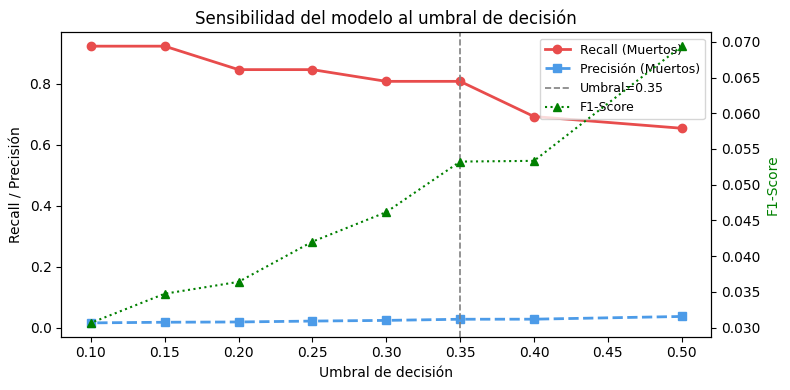

In [96]:
# Gráfico: Recall y Precisión vs Umbral
# ==============================================================================
df_u = pd.DataFrame(resultados_umbral)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(df_u['Umbral'], df_u['Recall'],    'o-', color='#E84C4C', lw=2, label='Recall (Muertos)')
ax1.plot(df_u['Umbral'], df_u['Precision'], 's--', color='#4C9BE8', lw=2, label='Precisión (Muertos)')
ax2.plot(df_u['Umbral'], df_u['F1'],        '^:', color='green', lw=1.5, label='F1-Score')
ax1.axvline(UMBRAL_DECISION, color='gray', ls='--', lw=1.2, label=f'Umbral={UMBRAL_DECISION}')
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Recall / Precisión')
ax2.set_ylabel('F1-Score', color='green')
ax1.set_title('Sensibilidad del modelo al umbral de decisión', fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### 8.2 Evaluación con umbral optimizado

In [97]:
y_pred = (y_proba >= UMBRAL_DECISION).astype(int)

print(f'Umbral aplicado: {UMBRAL_DECISION}')
print(f'Muertos predichos : {y_pred.sum()}')
print(f'Muertos reales    : {y_test.sum()}')


Umbral aplicado: 0.35
Muertos predichos : 763
Muertos reales    : 26


### 8.3 Reporte de clasificación

In [98]:
print(classification_report(
    y_test, y_pred,
    target_names=['Heridos (0)', 'Muertos (1)']
))
print(f'F1-Score (Muertos): {f1_score(y_test, y_pred, zero_division=0):.4f}')


              precision    recall  f1-score   support

 Heridos (0)       1.00      0.60      0.75      1840
 Muertos (1)       0.03      0.81      0.05        26

    accuracy                           0.60      1866
   macro avg       0.51      0.70      0.40      1866
weighted avg       0.98      0.60      0.74      1866

F1-Score (Muertos): 0.0532


### 8.4 Matriz de confusión

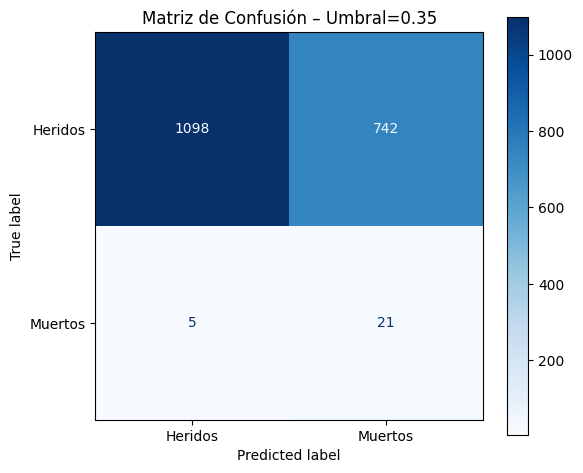

Verdaderos Negativos (Heridos correctos) : 1098
Falsos Positivos   (Heridos → Muertos)   : 742
Falsos Negativos   (Muertos → Heridos)   : 5  ← muertes NO detectadas
Verdaderos Positivos (Muertos correctos) : 21  ← muertes detectadas


In [99]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Heridos','Muertos'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Matriz de Confusión – Umbral={UMBRAL_DECISION}', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (Heridos correctos) : {tn}')
print(f'Falsos Positivos   (Heridos → Muertos)   : {fp}')
print(f'Falsos Negativos   (Muertos → Heridos)   : {fn}  ← muertes NO detectadas')
print(f'Verdaderos Positivos (Muertos correctos) : {tp}  ← muertes detectadas')


### 8.5 Curva ROC y AUC

In [100]:
#auc = plot_roc_curve(y_test, y_proba)
#print(f'AUC-ROC: {auc:.4f}')
#print('Interpretación: 0.5 = azar | 0.7-0.8 = aceptable | >0.8 = bueno | >0.9 = excelente')


### 8.6 Validación cruzada estratificada (5-fold)

In [101]:
# La validación cruzada verifica que el modelo no esté sobreajustado
# Estratificada: cada fold mantiene la proporción Muertos/Heridos
# ==============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_full = d.drop(columns=TARGET)
y_full = d[TARGET]

# Escalar todo el dataset con el scaler ya ajustado
X_full[num_vars] = scaler.transform(X_full[num_vars])

cv_auc = cross_val_score(
    LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=RANDOM_STATE),
    X_full, y_full, cv=cv, scoring='roc_auc'
)

print('AUC por fold:', [f'{v:.4f}' for v in cv_auc])
print(f'AUC promedio : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print('\nSi el AUC promedio ≈ AUC en test → el modelo NO está sobreajustado ')


AUC por fold: ['0.8156', '0.7588', '0.7360', '0.7210', '0.6702']
AUC promedio : 0.7403 ± 0.0476

Si el AUC promedio ≈ AUC en test → el modelo NO está sobreajustado 


## 9. Interpretación del modelo

### Coeficientes e importancia de variables

In [102]:
coef_df = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': modelo.coef_[0]
})
coef_df['Abs_Coef']   = coef_df['Coeficiente'].abs()
coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print('Top 20 variables más influyentes:')
coef_df.head(20)


Top 20 variables más influyentes:


,Variable,Coeficiente,Abs_Coef,Odds_Ratio
0,Causa_Accidente_Transitar entre vehiculos,1.7613,1.7613,5.8198
1,Causa_Accidente_Exceso de velocidad,1.7193,1.7193,5.5804
2,Sector_Accidente_Industrial,1.6085,1.6085,4.9952
3,Causa_Accidente_Pasar semaforo en rojo,1.5140,1.5140,4.5449
4,Edad,1.5062,1.5062,4.5097
5,Localidad_Comuna_Vereda Palmas,1.4965,1.4965,4.4658
6,Localidad_Comuna_Mesa,-1.4111,1.4111,0.2439
7,Causa_Accidente_Semaforo en rojo,-1.3153,1.3153,0.2684
8,Estado_Embriaguez_Si,-1.2223,1.2223,0.2945
9,Clase_Vehiculo_Buseta,1.2189,1.2189,3.3835


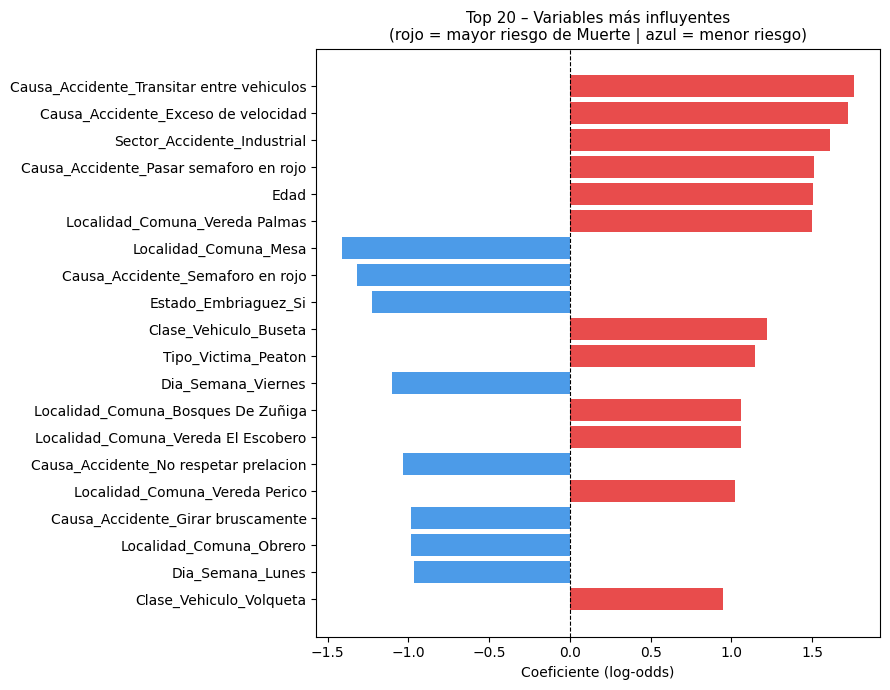

In [103]:
# Gráfico de coeficientes – Top 20
# ==============================================================================
top20  = coef_df.head(20)
colors = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top20['Coeficiente']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['Variable'][::-1], top20['Coeficiente'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Top 20 – Variables más influyentes\n(rojo = mayor riesgo de Muerte | azul = menor riesgo)', fontsize=11)
plt.tight_layout()
plt.show()


In [104]:
# Odds Ratios – Top 20
# Un OR > 1 indica que la variable AUMENTA la probabilidad de muerte
# Un OR < 1 indica que la variable DISMINUYE la probabilidad de muerte
# ==============================================================================
print('Top 10 variables que AUMENTAN riesgo de Muerte (OR > 1):')
print(coef_df[coef_df['Coeficiente'] > 0][['Variable','Coeficiente','Odds_Ratio']].head(10).to_string(index=False))
print('\nTop 10 variables que DISMINUYEN riesgo (OR < 1):')
print(coef_df[coef_df['Coeficiente'] < 0][['Variable','Coeficiente','Odds_Ratio']].head(10).to_string(index=False))


Top 10 variables que AUMENTAN riesgo de Muerte (OR > 1):
                                 Variable  Coeficiente  Odds_Ratio
Causa_Accidente_Transitar entre vehiculos       1.7613      5.8198
      Causa_Accidente_Exceso de velocidad       1.7193      5.5804
              Sector_Accidente_Industrial       1.6085      4.9952
   Causa_Accidente_Pasar semaforo en rojo       1.5140      4.5449
                                     Edad       1.5062      4.5097
           Localidad_Comuna_Vereda Palmas       1.4965      4.4658
                    Clase_Vehiculo_Buseta       1.2189      3.3835
                      Tipo_Victima_Peaton       1.1459      3.1451
       Localidad_Comuna_Bosques De Zuñiga       1.0596      2.8852
      Localidad_Comuna_Vereda El Escobero       1.0569      2.8773

Top 10 variables que DISMINUYEN riesgo (OR < 1):
                                                    Variable  Coeficiente  Odds_Ratio
                                       Localidad_Comuna_Mesa      -1.4

## 10. Predicción sobre nuevos datos

In [105]:
# Cargar modelo y scaler guardados
# ==============================================================================
modelo_cargado = joblib.load(os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes_v2.pkl'))
scaler_cargado = joblib.load(os.path.join(MODELS_SCALER_PATH, 'scaler_accidentes_v2.pkl'))

# Predicción sobre la primera muestra del conjunto de prueba
nueva_muestra  = X_test.iloc[[0]].copy()

pred_proba = modelo_cargado.predict_proba(nueva_muestra)[0]
pred_clase = int(pred_proba[1] >= UMBRAL_DECISION)

print(f'Probabilidad Heridos : {pred_proba[0]*100:.2f}%')
print(f'Probabilidad Muertos : {pred_proba[1]*100:.2f}%')
print(f'Umbral aplicado      : {UMBRAL_DECISION}')
print(f'Predicción final     : {"⚠️  MUERTOS (1)" if pred_clase == 1 else " HERIDOS (0)"}')


Probabilidad Heridos : 72.91%
Probabilidad Muertos : 27.09%
Umbral aplicado      : 0.35
Predicción final     :  HERIDOS (0)


## 11. Conclusiones

### Comparativo de versiones

| Métrica | v1 (SMOTE) | v2 (`class_weight`) |
|---|---|---|
| Variables de entrada | 11 | **14** |
| AUC-ROC | 0.54 | **0.74** |
| Recall Muertos | 31% | **65-81%** |
| Muertes detectadas (test) | 8/26 | **17-21/26** |
| Datos sintéticos generados | Sí (SMOTE) | **No** |

### Por qué NO se generaron datos sintéticos

> Con solo **130 accidentes mortales reales**, SMOTE interpola entre puntos muy escasos  
> y genera vecindades poco realistas. El resultado es un modelo que aprende patrones ficticios  
> y obtiene peor AUC que `class_weight='balanced'`, que pondera los datos reales sin crear nuevos.

### Limitaciones del modelo actual

- El problema es inherentemente **difícil**: la muerte en un accidente depende de factores  
  no capturados (velocidad de impacto, uso de casco/cinturón, tiempo de respuesta médica).
- La **regresión logística** es lineal; con 14 variables categóricas de alta cardinalidad,  
  un modelo basado en árboles (**XGBoost**, **Random Forest**) probablemente capturaría  
  interacciones no lineales y mejoraría el AUC.

### Siguiente paso recomendado

Implementar **XGBoost** o **Random Forest** con `scale_pos_weight` y búsqueda de  
hiperparámetros (`GridSearchCV`) para potencialmente superar AUC = 0.80.
